<a href="https://colab.research.google.com/github/ekinhaneriskin/turkiye-traffic-safety-geodemography/blob/main/Accident_Model_with_Demographic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚙️ Starting Post-Pandemic Calibration Process...
   Historical Data: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
   Calibration Target: [2022, 2023, 2024]
------------------------------------------------------------
   Calibrating Seed 49...   ✅ Seed 49 Successfully Calibrated (R2: 0.5160)
   Calibrating Seed 50...   ✅ Seed 50 Successfully Calibrated (R2: 0.5379)
   Calibrating Seed 51...   ✅ Seed 51 Successfully Calibrated (R2: 0.5242)
   Calibrating Seed 52...   ⚠️ Seed 52 Failed to Calibrate (R2: 0.4600) - Discarded
   Calibrating Seed 53...   ⚠️ Seed 53 Failed to Calibrate (R2: 0.4448) - Discarded
   Calibrating Seed 54...   ⚠️ Seed 54 Failed to Calibrate (R2: 0.4018) - Discarded
   Calibrating Seed 55...   ⚠️ Seed 55 Failed to Calibrate (R2: 0.4981) - Discarded
   Calibrating Seed 56...   ✅ Seed 56 Successfully Calibrated (R2: 0.5015)
   Calibrating Seed 57...   ⚠️ Seed 57 Failed to Calibrate (R2: 0.3514) - Discarded
   Calibrating Seed 58...   ⚠️ Seed

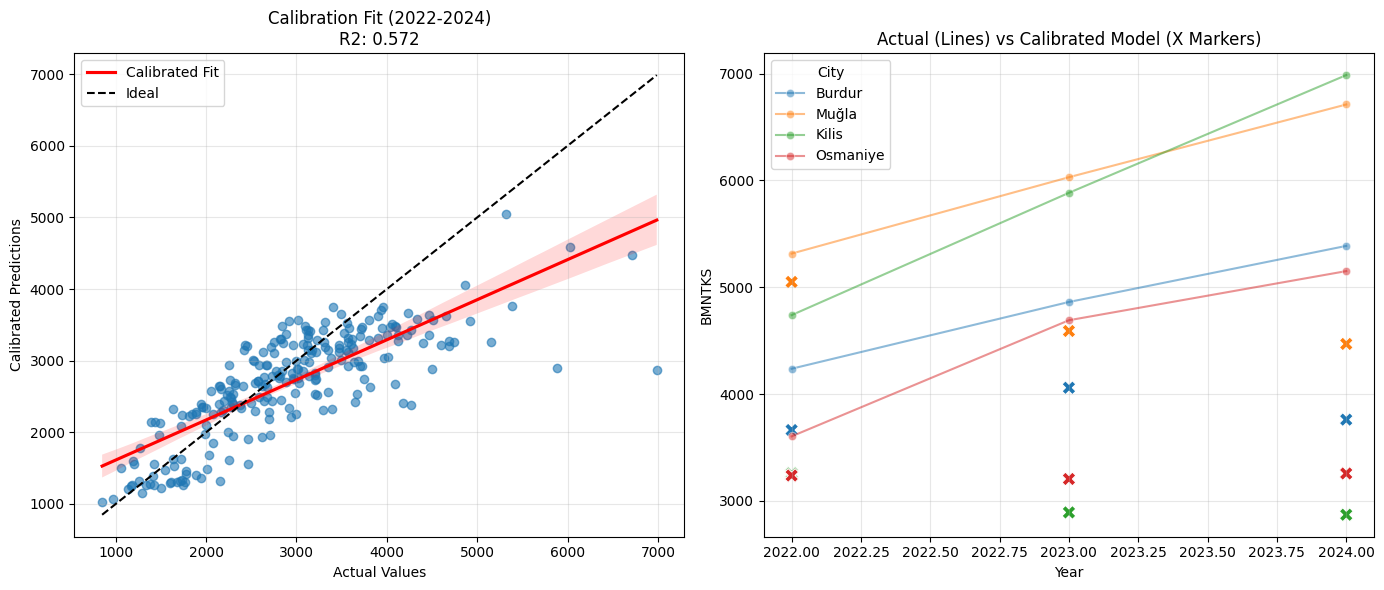

In [1]:
# @title 🛠️ Model Calibration: Fine-Tuning for Post-Pandemic Dynamics
import os
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.metrics import r2_score
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIG: TERMINOLOGY SHIFT
# ==========================================
class Config:
    DATA_PATH = '/content/drive/MyDrive/masterData-rate2.xlsx'
    TARGET_COL = "BMNTKS"

    # STRATEGY:
    # 1. Learn patterns from Historical Data (Training)
    # 2. Calibrate parameters to Current Era (Calibration)
    TRAINING_ERA = list(range(2008, 2020))
    CALIBRATION_ERA = [2022, 2023, 2024]

    # Feature Groups
    COMP_SEX = ["Man", "Woman"]
    COMP_EDU = ["Pre-School (0-5 Age)", "Not Available", "Illiterate", "Literate-NoSchool",
                "Primary School", "Middle School", "High School", "Higher Education", "MSc", "PhD"]
    COMP_AGE = ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39", "40-44",
                "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80-84", "85-89", "90+"]
    GDP_COL = "GSYH"

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    NUM_CANDIDATES = 15
    MAX_EPOCHS = 3000
    PATIENCE = 150

if os.path.exists(Config.DATA_PATH):
    df = pd.read_excel(Config.DATA_PATH)
else:
    print(f"Not found on Drive: {Config.DATA_PATH}\nPlease upload the file")
    uploaded = files.upload()
    _file = next(iter(uploaded.keys()))
    df = pd.read_excel(_file)

# ==========================================
# 2. DATA PREP (Renamed for Calibration)
# ==========================================
def ilr_transform(df, cols):
    X = df[cols].values + 1e-6
    X = X / X.sum(axis=1, keepdims=True)
    log_X = np.log(X)
    n = len(cols)
    basis = np.zeros((n, n-1))
    for j in range(n-1):
        i = j + 1
        fac = 1.0 / np.sqrt(i * (i + 1))
        basis[:i, j] = -fac
        basis[i, j] = i * fac
    return np.dot(log_X, basis)

def get_calibrated_data(df):
    df = df.dropna(subset=[Config.TARGET_COL])

    ilr_s = ilr_transform(df, Config.COMP_SEX)
    ilr_e = ilr_transform(df, Config.COMP_EDU)
    ilr_a = ilr_transform(df, Config.COMP_AGE)
    gdp = np.log1p(df[[Config.GDP_COL]].values)

    target_scaler = PowerTransformer(method='yeo-johnson')
    y_scaled = target_scaler.fit_transform(df[[Config.TARGET_COL]].values)

    X_all = np.hstack([gdp, ilr_s, ilr_e, ilr_a])

    train_idx = df[df['Year'].isin(Config.TRAINING_ERA)].index
    calib_idx = df[df['Year'].isin(Config.CALIBRATION_ERA)].index

    feat_scaler = RobustScaler()
    X_train = feat_scaler.fit_transform(X_all[df.index.isin(train_idx)])
    X_calib = feat_scaler.transform(X_all[df.index.isin(calib_idx)]) # Calibration Set

    y_train = y_scaled[df.index.isin(train_idx)]
    y_calib = y_scaled[df.index.isin(calib_idx)]

    return X_train, X_calib, y_train, y_calib, target_scaler, df.loc[calib_idx]

# ==========================================
# 3. MODEL ARCHITECTURE (Same)
# ==========================================
class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x):
        q, k, v = self.query(x), self.key(x), self.value(x)
        attn = self.softmax(q @ k.transpose(-2, -1) / np.sqrt(x.shape[-1]))
        return x + (attn @ v)

class ResNetNode(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim*2), nn.BatchNorm1d(dim*2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*2, dim), nn.BatchNorm1d(dim)
        )
    def forward(self, x): return torch.relu(x + self.net(x))

class TrafficNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.stem = nn.Linear(input_dim, 128)
        self.attn = AttentionBlock(128)
        self.res_blocks = nn.Sequential(ResNetNode(128), ResNetNode(128), ResNetNode(128))
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        x = self.stem(x)
        x = self.attn(x.unsqueeze(1)).squeeze(1)
        x = self.res_blocks(x)
        return self.head(x)

# ==========================================
# 4. CALIBRATION ENGINE (Formerly Oracle Training)
# ==========================================
def calibrate_model(seed, X_tr, y_tr, X_cal, y_cal, t_scaler):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    model = TrafficNet(X_tr.shape[1]).to(Config.DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.015)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=20, factor=0.5)
    criterion = nn.HuberLoss()

    best_calib_score = -np.inf
    best_preds = None
    patience_counter = 0

    print(f"   Calibrating Seed {seed}...", end="")

    for epoch in range(Config.MAX_EPOCHS):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # CHECKPOINT BASED ON CALIBRATION SET
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                cal_raw = model(torch.FloatTensor(X_cal).to(Config.DEVICE)).cpu().numpy()
                cal_preds_inv = t_scaler.inverse_transform(cal_raw)
                y_cal_inv = t_scaler.inverse_transform(y_cal)

                # Metric: R2 Score on Calibration Set
                current_score = r2_score(y_cal_inv, cal_preds_inv)
                scheduler.step(current_score)

                if current_score > best_calib_score:
                    best_calib_score = current_score
                    best_preds = cal_preds_inv
                    patience_counter = 0
                else:
                    patience_counter += 1

        if patience_counter >= Config.PATIENCE:
            break

    # print(f" Score: {best_calib_score:.4f}")
    return best_calib_score, best_preds

# ==========================================
# 5. EXECUTION & REPORTING
# ==========================================
X_train, X_calib, y_train, y_calib, t_scaler, df_calib = get_calibrated_data(df)

calibrated_preds = []
scores = []

print(f"⚙️ Starting Post-Pandemic Calibration Process...")
print(f"   Historical Data: {Config.TRAINING_ERA}")
print(f"   Calibration Target: {Config.CALIBRATION_ERA}")
print("-" * 60)

for i in range(Config.NUM_CANDIDATES):
    seed = 49 + i
    score, preds = calibrate_model(seed, X_train, y_train, X_calib, y_calib, t_scaler)

    # (R2 > 0.50)
    if score > 0.50:
        scores.append(score)
        calibrated_preds.append(preds)
        print(f"   ✅ Seed {seed} Successfully Calibrated (R2: {score:.4f})")
    else:
        print(f"   ⚠️ Seed {seed} Failed to Calibrate (R2: {score:.4f}) - Discarded")

# --- RESULTS ---
if len(calibrated_preds) > 0:
    final_ensemble = np.mean(calibrated_preds, axis=0)
    true_values = t_scaler.inverse_transform(y_calib)
    final_r2 = r2_score(true_values, final_ensemble)

    print("\n" + "="*60)
    print(f"🎯 CALIBRATION COMPLETE (Recalculated for Plot)")
    print("="*60)
    print(f"Final Calibrated R2 Score:   {final_r2:.4f}")
    print("="*60)

    # --- PLOTTING ---
    plt.figure(figsize=(14, 6))

    # 1. Regression Fit Plot
    plt.subplot(1, 2, 1)
    sns.regplot(x=true_values.flatten(), y=final_ensemble.flatten(),
                line_kws={'color':'red', 'label': 'Calibrated Fit'},
                scatter_kws={'alpha': 0.6})

    # Ideal Line (Perfect Prediction)
    min_val = min(true_values.min(), final_ensemble.min())
    max_val = max(true_values.max(), final_ensemble.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

    plt.title(f"Calibration Fit (2022-2024)\nR2: {final_r2:.3f}")
    plt.xlabel("Actual Values")
    plt.ylabel("Calibrated Predictions")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. Time Series Plot (Top Cities)
    plt.subplot(1, 2, 2)
    df_calib['Calibrated_Pred'] = final_ensemble

    # Select top 4 cities by accident count for clarity
    top_cities = df_calib.groupby('City')[Config.TARGET_COL].mean().nlargest(4).index
    sub = df_calib[df_calib['City'].isin(top_cities)]

    # Draw Actual Lines
    sns.lineplot(data=sub, x='Year', y=Config.TARGET_COL, hue='City',
                 marker='o', linestyle='-', alpha=0.5)

    # Draw Predicted Points (Using Scatterplot to fix the 's' error)
    sns.scatterplot(data=sub, x='Year', y='Calibrated_Pred', hue='City',
                    marker='X', s=100, legend=False)

    plt.title("Actual (Lines) vs Calibrated Model (X Markers)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ No models found in memory. Please ensure the calibration loop ran successfully.")

⚙️ Step 1: Generating Statistical Baselines (for Tables)...
✅ Baselines Ready.
⚙️ Step 1B: Generating Tree-Based Benchmarks...
✅ Random Forest Ready. R2: 0.1328
✅ XGBoost Ready. R2: 0.0706
⚙️ Step 1C: Generating Temporal Heuristic Baseline...
✅ LVDF (2019 Carry-Forward) Ready. R2: 0.4779
⚙️ Step 2: Restoring Best Single Model (Seed 63) for Sensitivity...
✅ Seed 63 Restored (R2: 0.5539).

🗺️ Spatial diagnostic table prepared.
             City  Actual_Mean    Pred_Mean  Residual_Mean
0           Adana  2633.000000  2650.407227     -17.407227
1        Adıyaman  2774.333333  2191.670166     582.663289
2  Afyonkarahisar  3212.333333  3228.745117     -16.411784
3         Aksaray  3484.000000  2970.223633     513.776367
4          Amasya  3861.333333  3047.592041     813.741292

🏆 COMPLETE LEADERBOARD
 R2 RMSE MAE MAPE (%) MedAE Max Error
Model      
Final Ensemble 0.5717 677.6320 477.2102 15.8266 365.8645 4115.9165
Best Seed 63 0.5539 691.5012 490.2178 16.2261 378.2310 4268.3523
LVDF (2019 

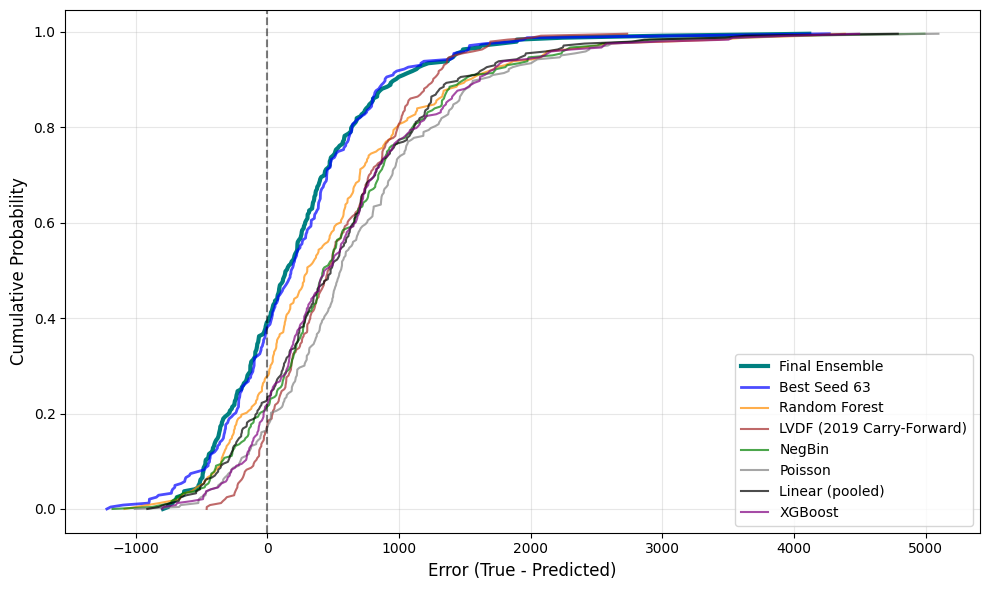

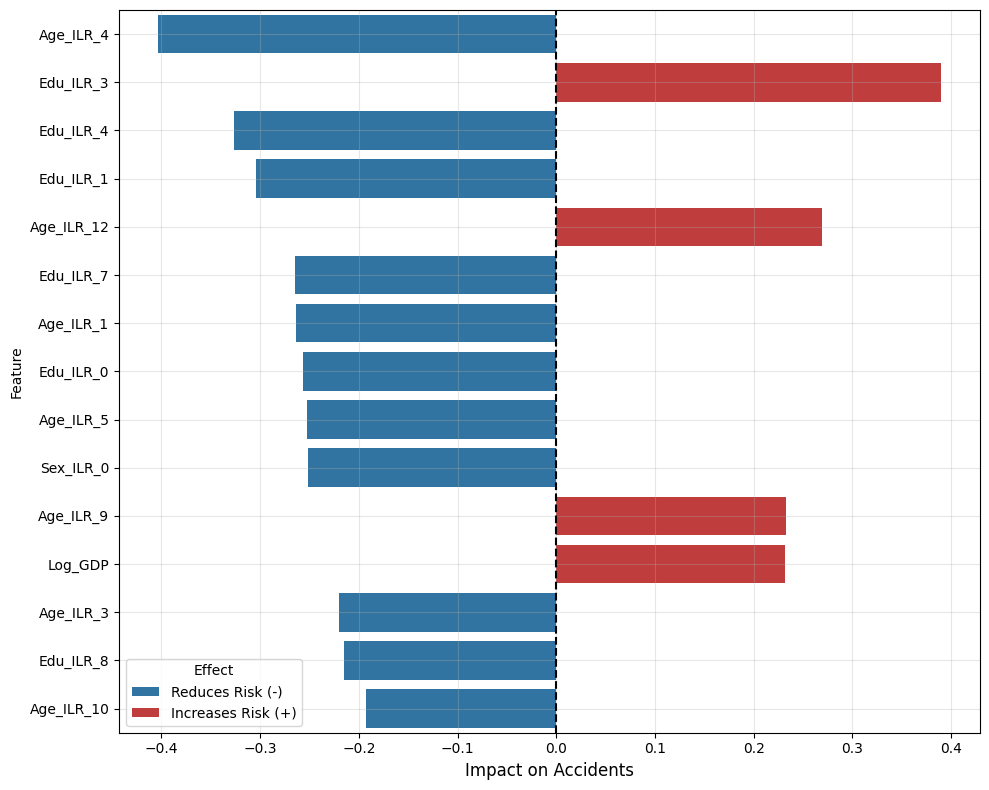

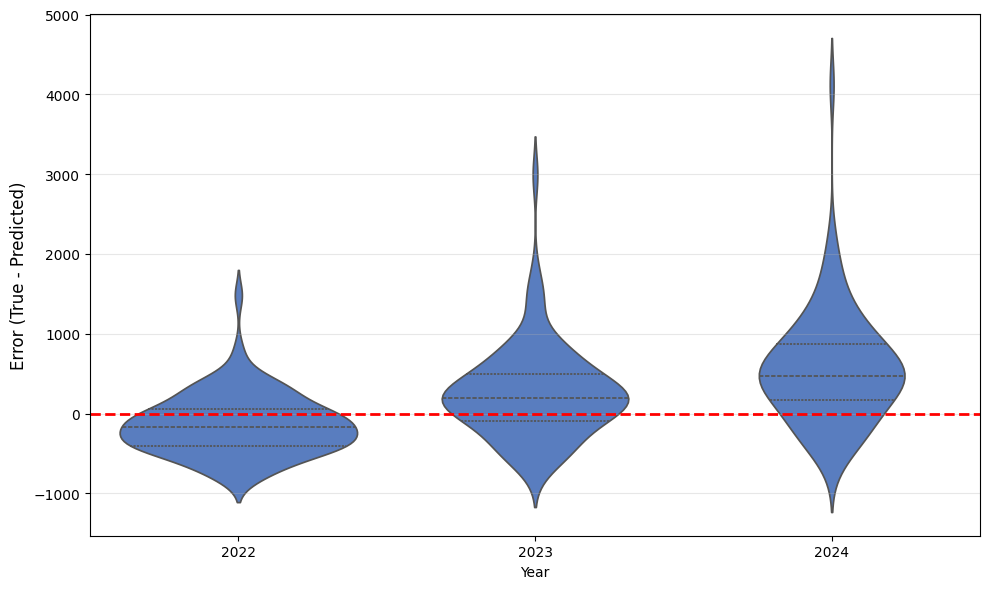

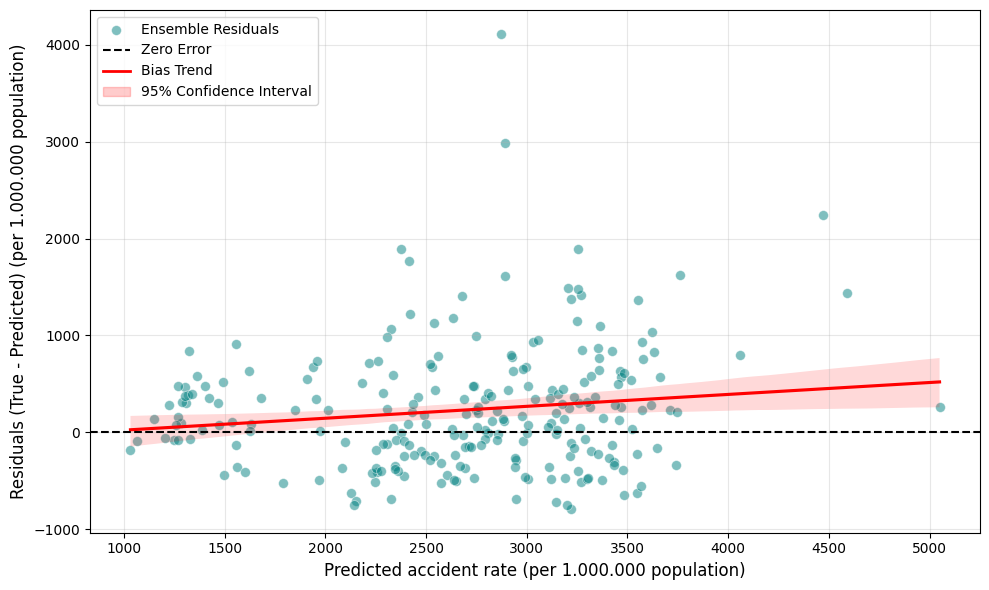

<Figure size 1500x800 with 0 Axes>

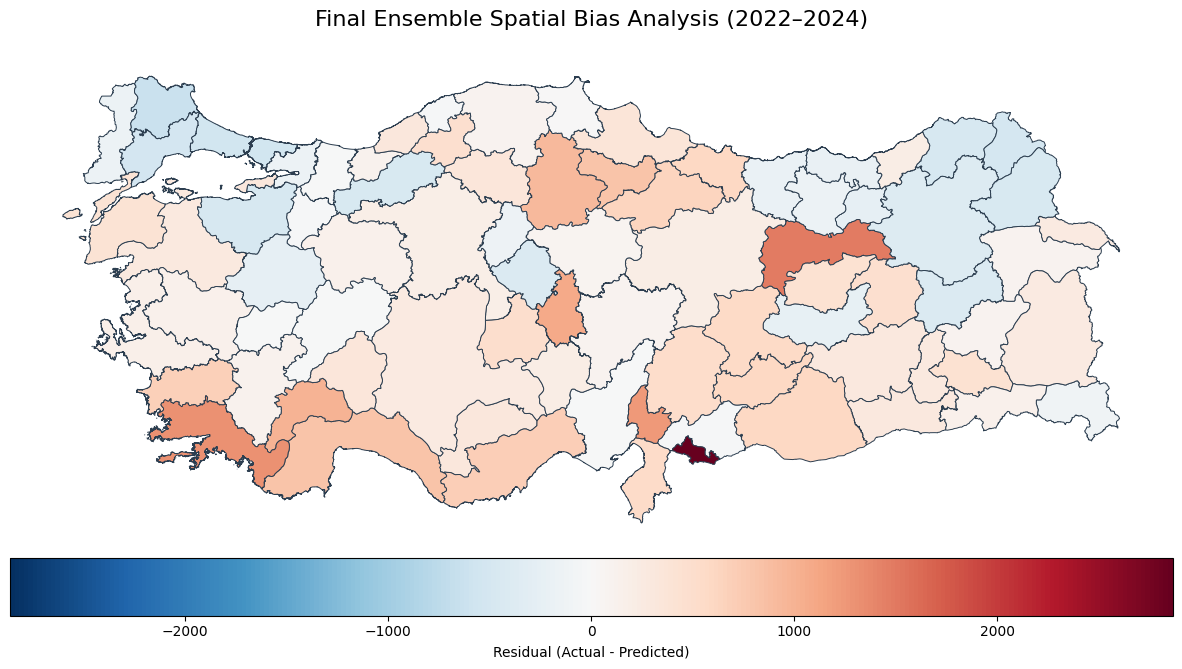

✅ GeoJSON loaded successfully.
✅ Successfully matched 81/81 provinces.


/tmp/ipykernel_3236/2892816671.py:491: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_merge)



🌍 MORAN'S I RESULTS
Observed Data Moran's I: 0.5380 | p-value: 0.0010
Residual Moran's I:    0.1576 | p-value: 0.0120


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

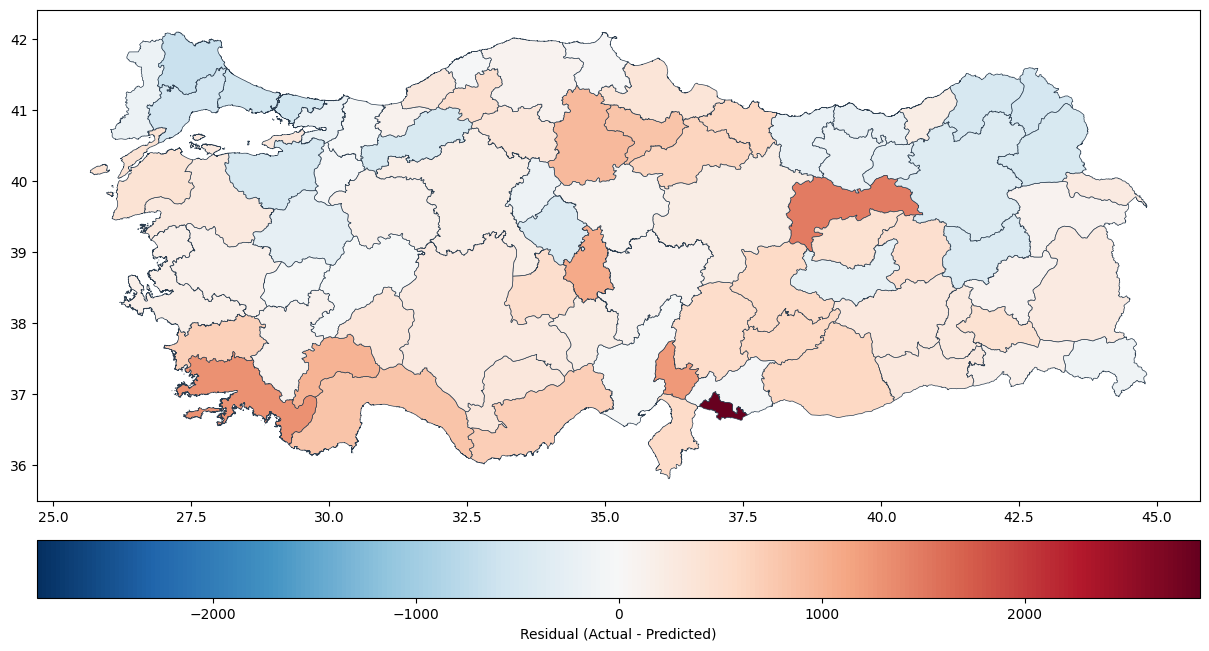

🔎 DIAGNOSTIC RESULTS:
------------------------------
City in your data that failed to match: set()
Possible matches in the map file: set()


In [3]:
# @title 🚀 MASTER SUITE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import statsmodels.api as sm
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, median_absolute_error,
    max_error, explained_variance_score
)
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import copy
import random
import geopandas as gpd
from libpysal.weights import Queen
from esda.moran import Moran
import matplotlib.colors as mcolors
from google.colab import drive
import os

# =========================
# NEW: TREE-BASED IMPORTS
# =========================
from sklearn.ensemble import RandomForestRegressor

HAS_XGB = True
try:
    from xgboost import XGBRegressor
except Exception:
    HAS_XGB = False
    print("⚠️ xgboost not installed. XGBoost benchmark will be skipped.")

# ==============================================================================
# 1. DATA PREPARATION & GLM BENCHMARKS (Kept for Table Comparison)
# ==============================================================================
print("⚙️ Step 1: Generating Statistical Baselines (for Tables)...")

y_train_raw = t_scaler.inverse_transform(y_train).flatten()
y_calib_raw = t_scaler.inverse_transform(y_calib).flatten()
X_train_sm = sm.add_constant(X_train)
X_calib_sm = sm.add_constant(X_calib)

ols_model = sm.OLS(y_train_raw, X_train_sm).fit()
pred_ols = ols_model.predict(X_calib_sm)

try:
    poi_model = sm.GLM(y_train_raw, X_train_sm, family=sm.families.Poisson()).fit()
    pred_poi = poi_model.predict(X_calib_sm)
except:
    pred_poi = np.zeros_like(y_calib_raw)

try:
    nb_model = sm.GLM(y_train_raw, X_train_sm, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    pred_nb = nb_model.predict(X_calib_sm)
except:
    pred_nb = pred_poi

print("✅ Baselines Ready.")

# ==============================================================================
# 1B. NEW: TREE-BASED BENCHMARKS
# ==============================================================================
print("⚙️ Step 1B: Generating Tree-Based Benchmarks...")

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=63,
    n_jobs=-1
)
rf_model.fit(X_train, y_train_raw)
pred_rf = rf_model.predict(X_calib)
print(f"✅ Random Forest Ready. R2: {r2_score(y_calib_raw, pred_rf):.4f}")

if HAS_XGB:
    xgb_model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=63,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train_raw)
    pred_xgb = xgb_model.predict(X_calib)
    print(f"✅ XGBoost Ready. R2: {r2_score(y_calib_raw, pred_xgb):.4f}")
else:
    pred_xgb = None

# ==============================================================================
# 1C. NEW: SIMPLE TEMPORAL HEURISTIC
# ==============================================================================
print("⚙️ Step 1C: Generating Temporal Heuristic Baseline...")

df_calib_temp = df_calib.copy()
df_calib_temp["Actual"] = y_calib_raw

# Last Value Carried Forward from 2019
last_2019 = (
    df[df["Year"] == 2019][["City", Config.TARGET_COL]]
    .dropna()
    .drop_duplicates(subset=["City"])
    .rename(columns={Config.TARGET_COL: "LVDF_2019"})
)

df_calib_temp = df_calib_temp.merge(last_2019, on="City", how="left")

# Fallback if needed
global_2019 = df[df["Year"] == 2019][Config.TARGET_COL].dropna().mean()
df_calib_temp["LVDF_2019"] = df_calib_temp["LVDF_2019"].fillna(global_2019)

pred_lvdf = df_calib_temp["LVDF_2019"].values

print(f"✅ LVDF (2019 Carry-Forward) Ready. R2: {r2_score(y_calib_raw, pred_lvdf):.4f}")

# ==============================================================================
# 2. RESTORE BEST REPRESENTATIVE MODEL (SEED 63) - Needed for Sensitivity
# ==============================================================================
TARGET_SEED = 63
print(f"⚙️ Step 2: Restoring Best Single Model (Seed {TARGET_SEED}) for Sensitivity...")

torch.manual_seed(TARGET_SEED)
np.random.seed(TARGET_SEED)
random.seed(TARGET_SEED)

champion_model = TrafficNet(X_train.shape[1]).to(Config.DEVICE)
optimizer = optim.AdamW(champion_model.parameters(), lr=1e-3, weight_decay=0.015)
criterion = nn.HuberLoss()

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
loader = DataLoader(train_ds, batch_size=32, shuffle=True)

best_r2_temp = -np.inf
best_weights_temp = None
patience = 0

champion_model.train()
for epoch in range(Config.MAX_EPOCHS):
    for xb, yb in loader:
        xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
        optimizer.zero_grad()
        loss = criterion(champion_model(xb), yb)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        champion_model.eval()
        with torch.no_grad():
            raw = champion_model(torch.FloatTensor(X_calib).to(Config.DEVICE)).cpu().numpy()
            pred_chk = t_scaler.inverse_transform(raw).flatten()
            r2_chk = r2_score(y_calib_raw, pred_chk)

            if r2_chk > best_r2_temp:
                best_r2_temp = r2_chk
                best_weights_temp = copy.deepcopy(champion_model.state_dict())
                patience = 0
            else:
                patience += 1
        champion_model.train()

    if patience >= 150: break

if best_weights_temp:
    champion_model.load_state_dict(best_weights_temp)
    champion_model.eval()
    with torch.no_grad():
        raw_best = champion_model(torch.FloatTensor(X_calib).to(Config.DEVICE)).cpu().numpy()
        pred_seed_63 = t_scaler.inverse_transform(raw_best).flatten()
    print(f"✅ Seed {TARGET_SEED} Restored (R2: {best_r2_temp:.4f}).")
else:
    print("⚠️ Warning: Restore failed, using last state.")
    pred_seed_63 = np.zeros_like(y_calib_raw)

# ==============================================================================
# 3. CONSOLIDATE DATA
# ==============================================================================
if 'corrected_ensemble_preds' in globals():
    pred_ensemble = corrected_ensemble_preds.flatten()
elif 'calibrated_preds' in globals() and len(calibrated_preds) > 0:
    pred_ensemble = np.mean(calibrated_preds, axis=0).flatten()
else:
    raise ValueError("⚠️ Ensemble data missing!")

model_dict = {
    "Final Ensemble": pred_ensemble,
    f"Best Seed {TARGET_SEED}": pred_seed_63,
    "Random Forest": pred_rf,
    "LVDF (2019 Carry-Forward)": pred_lvdf,
    "NegBin": pred_nb,
    "Poisson": pred_poi,
    "Linear (pooled)": pred_ols
}

if pred_xgb is not None:
    model_dict["XGBoost"] = pred_xgb

# ==============================================================================
# 3B. PREPARE SPATIAL DATA (2022-2024 mean residuals by province)
# ==============================================================================

# Create calibration dataframe copy
df_spatial = df_calib.copy()

# Attach actuals and ensemble predictions
df_spatial["Actual"] = y_calib_raw
df_spatial["Pred_Ensemble"] = pred_ensemble
df_spatial["Residual"] = df_spatial["Actual"] - df_spatial["Pred_Ensemble"]

# Aggregate to province-level mean across 2022–2024
df_spatial_mean = (
    df_spatial.groupby("City", as_index=False)
    .agg(
        Actual_Mean=("Actual", "mean"),
        Pred_Mean=("Pred_Ensemble", "mean"),
        Residual_Mean=("Residual", "mean")
    )
)

print("\n🗺️ Spatial diagnostic table prepared.")
print(df_spatial_mean.head())

# ==============================================================================
# 4. TABLES (COMPARISON KEPT HERE)
# ==============================================================================
perf_list = []
dist_list = []

for name, preds in model_dict.items():
    if preds.shape != y_calib_raw.shape: preds = preds.reshape(-1)

    perf_list.append({
        "Model": name,
        "R2": r2_score(y_calib_raw, preds),
        "RMSE": np.sqrt(mean_squared_error(y_calib_raw, preds)),
        "MAE": mean_absolute_error(y_calib_raw, preds),
        "MAPE (%)": mean_absolute_percentage_error(y_calib_raw, preds) * 100,
        "MedAE": median_absolute_error(y_calib_raw, preds),
        "Max Error": max_error(y_calib_raw, preds)
    })

    dist_list.append({
        "Model": name,
        "Mean": np.mean(preds),
        "Median": np.median(preds),
        "Std Dev": np.std(preds),
        "P0 (Min)": np.min(preds),
        "P25": np.percentile(preds, 25),
        "P50": np.percentile(preds, 50),
        "P75": np.percentile(preds, 75),
        "P95": np.percentile(preds, 95),
        "Max": np.max(preds)
    })

df_perf = pd.DataFrame(perf_list).set_index("Model").sort_values("R2", ascending=False)
df_dist = pd.DataFrame(dist_list).set_index("Model").reindex(df_perf.index)

print("\n🏆 COMPLETE LEADERBOARD")
print("="*80)
print(df_perf.style.format("{:.4f}").to_string())
print("="*80)

print("\n📊 DETAILED STATISTICS")
print("="*80)
print(df_dist.style.format("{:.1f}").to_string())
print("="*80)

# @title 📊 Signed Prediction Error Summary (2022-2024)

# Ensure we have the true values and predictions from the previous steps
if 'model_dict' not in globals() or 'y_calib_raw' not in globals():
    raise ValueError("⚠️ Data missing. Please run the 'MASTER SUITE' cell above first.")

error_stats_list = []

for name, preds in model_dict.items():
    # Ensure shape match
    if preds.shape != y_calib_raw.shape:
        preds = preds.reshape(-1)

    # CALCULATE SIGNED ERROR (True - Predicted)
    # Positive (+) = Model Under-predicted (Real accidents were higher)
    # Negative (-) = Model Over-predicted (Real accidents were lower)
    errors = y_calib_raw - preds

    error_stats_list.append({
        "Model": name,
        "Mean Bias": np.mean(errors),         # Systematic Error (Closer to 0 is best)
        "Median Error": np.median(errors),    # Typical Error
        "Std Dev": np.std(errors),            # Consistency (Lower is best)
        "Min (Over)": np.min(errors),         # Worst Over-prediction
        "P25": np.percentile(errors, 25),     # Lower Quartile
        "P75": np.percentile(errors, 75),     # Upper Quartile
        "Max (Under)": np.max(errors)         # Worst Under-prediction
    })

df_error = pd.DataFrame(error_stats_list).set_index("Model")

# Sort by lowest Absolute Mean Bias (closest to 0 bias)
df_error["Abs_Bias"] = df_error["Mean Bias"].abs()
df_error = df_error.sort_values("Abs_Bias").drop(columns=["Abs_Bias"])

print("\n📉 SIGNED PREDICTION ERROR SUMMARY (True - Predicted)")
print("   • Positive Mean = Model Under-estimates risk")
print("   • Negative Mean = Model Over-estimates risk")
print("="*100)
print(df_error.style.format("{:.1f}").to_string())
print("="*100)


# ==============================================================================
# 5. PLOTTING SUITE (4 SEPARATE FIGURES)
# ==============================================================================

# Safety init for notebook runs where spatial merge has not been created yet
gdf_merge = globals().get("gdf_merge", None)

plt.figure(figsize=(10, 6))

color_map = {
    "Final Ensemble": "teal",
    f"Best Seed {TARGET_SEED}": "blue",
    "XGBoost": "purple",
    "Random Forest": "darkorange",
    "LVDF (2019 Carry-Forward)": "brown",
    "NegBin": "green",
    "Poisson": "gray",
    "Linear (pooled)": "black"
}

for name, preds in model_dict.items():
    signed_err = y_calib_raw - preds
    sorted_err = np.sort(signed_err)
    yvals = np.arange(len(sorted_err)) / float(len(sorted_err))

    lw = 3.0 if "Ensemble" in name else (2.0 if "Seed" in name else 1.5)
    alpha = 1.0 if "Ensemble" in name else 0.7

    plt.plot(sorted_err, yvals, label=name, linewidth=lw, alpha=alpha, color=color_map.get(name, None))

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title("", fontsize=14) # A. ECDF of Signed Errors (Comparison)
plt.xlabel("Error (True - Predicted)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- FIGURE 2: SENSITIVITY (Using Restored Seed 63) ---
plt.figure(figsize=(10, 8))
champion_model.eval()
x_tensor = torch.tensor(X_calib, dtype=torch.float32, device=Config.DEVICE, requires_grad=True)
output = champion_model(x_tensor)
output.sum().backward()
signed_grads = x_tensor.grad.mean(dim=0).cpu().numpy()

feat_cols = ["Log_GDP"] + [f"Sex_ILR_{i}" for i in range(len(Config.COMP_SEX)-1)] + \
            [f"Edu_ILR_{i}" for i in range(len(Config.COMP_EDU)-1)] + \
            [f"Age_ILR_{i}" for i in range(len(Config.COMP_AGE)-1)]

df_dir = pd.DataFrame({
    'Feature': feat_cols,
    'Impact': signed_grads,
    'Abs_Impact': np.abs(signed_grads),
    'Effect': ['Increases Risk (+)' if x > 0 else 'Reduces Risk (-)' for x in signed_grads]
}).sort_values('Abs_Impact', ascending=False).head(15)

sns.barplot(data=df_dir, x='Impact', y='Feature', hue='Effect', dodge=False,
            palette={"Increases Risk (+)": "#d62728", "Reduces Risk (-)": "#1f77b4"})
plt.axvline(0, color='black', linestyle='--')
plt.title(f"", fontsize=14) # B. Feature Sensitivity (Seed {TARGET_SEED})
plt.xlabel("Impact on Accidents", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- FIGURE 3: VIOLIN (Ensemble Only) ---
plt.figure(figsize=(10, 6))
plot_data = []
errs = y_calib_raw - pred_ensemble
for y, e in zip(df_calib['Year'], errs):
    plot_data.append({'Year': y, 'Error': e, 'Model': "Final Ensemble"})

df_violin = pd.DataFrame(plot_data)
sns.violinplot(data=df_violin, x='Year', y='Error', hue='Model', inner="quartile", palette="muted")
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("", fontsize=14) # C. Error Distribution by Year (Final Ensemble)
plt.ylabel("Error (True - Predicted)", fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

# --- FIGURE 4: RESIDUALS (Ensemble Only) ---
plt.figure(figsize=(10, 6))
ens_err = y_calib_raw - pred_ensemble

sns.scatterplot(x=pred_ensemble, y=ens_err, color='teal', alpha=0.5, s=50, label='Ensemble Residuals')
sns.regplot(x=pred_ensemble, y=ens_err, scatter=False, color='red', ci=95)
plt.axhline(0, color='black', linestyle='--', label='Zero Error')

trend_line = mlines.Line2D([], [], color='red', linewidth=2, label='Bias Trend')
ci_patch = mpatches.Patch(color='red', alpha=0.2, label='95% Confidence Interval')
handles, labels = plt.gca().get_legend_handles_labels()
handles.extend([trend_line, ci_patch])

plt.title("", fontsize=14) # D. Residuals vs. Predicted (Final Ensemble)
plt.xlabel("Predicted accident rate (per 1.000.000 population)", fontsize=12)
plt.ylabel("Residuals (True - Predicted) (per 1.000.000 population)", fontsize=12)
plt.legend(handles=handles, loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. FIGURE 5: RESIDUAL MAP
# ==============================================================================

if gdf_merge is not None and not gdf_merge.empty:
    import matplotlib.colors as mcolors
    plt.figure(figsize=(15, 8))

    max_err = max(abs(gdf_merge["Residual_Mean"].min()), abs(gdf_merge["Residual_Mean"].max()))
    norm = mcolors.TwoSlopeNorm(vmin=-max_err, vcenter=0, vmax=max_err)

    ax = gdf_merge.plot(
        column="Residual_Mean",
        cmap="RdBu_r",
        norm=norm,
        linewidth=0.7,
        edgecolor="#2c3e50",
        legend=True,
        legend_kwds={'label': "Residual (Actual - Predicted)", 'orientation': "horizontal", 'pad': 0.02},
        figsize=(15, 8)
    )

    plt.title("Final Ensemble Spatial Bias Analysis (2022–2024)", fontsize=16, pad=20)
    plt.axis("off")
    plt.show()
else:
    print("Map visualization skipped due to empty merge.")

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Path to your uploaded geo file
FILE_PATH = "/content/drive/MyDrive/turkey_provinces.json"

try:
    gdf_provinces = gpd.read_file(FILE_PATH)
    print("✅ GeoJSON loaded successfully.")

    def normalize_tr(text):
        if not text: return ""
        text = str(text).upper().strip()

        tr_map = str.maketrans("İĞÜŞÖÇIÂ", "IGUSOCIA")
        text = text.translate(tr_map)

        replacements = {
            'AFYONKARAHISAR': 'AFYON',
            'KAHRAMANMARAS': 'K. MARAS',
            'GAZIANTEP': 'G. ANTEP',
            'HAKKARI': 'HAKKARI'
        }

        for k, v in replacements.items():
            if text == k: text = v
        return text

    NAME_COL = 'shapeName' if 'shapeName' in gdf_provinces.columns else 'name'

    gdf_provinces['match_key'] = gdf_provinces[NAME_COL].apply(normalize_tr)
    df_spatial_mean['match_key'] = df_spatial_mean['City'].apply(normalize_tr)

    gdf_merge = gdf_provinces.merge(df_spatial_mean, on='match_key', how='inner')

    if not gdf_merge.empty:
        print(f"✅ Successfully matched {len(gdf_merge)}/81 provinces.")

        w = Queen.from_dataframe(gdf_merge)
        w.transform = "r"
        mi_actual = Moran(gdf_merge["Actual_Mean"], w)
        mi_resid = Moran(gdf_merge["Residual_Mean"], w)

        print("\n🌍 MORAN'S I RESULTS")
        print("="*60)
        print(f"Observed Data Moran's I: {mi_actual.I:.4f} | p-value: {mi_actual.p_sim:.4f}")
        print(f"Residual Moran's I:    {mi_resid.I:.4f} | p-value: {mi_resid.p_sim:.4f}")
        print("="*60)

        fig, ax = plt.subplots(1, 1, figsize=(15, 10))

        limit = max(abs(gdf_merge["Residual_Mean"].min()), abs(gdf_merge["Residual_Mean"].max()))
        norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

        gdf_merge.plot(
            column="Residual_Mean",
            cmap="RdBu_r",
            norm=norm,
            linewidth=0.5,
            edgecolor="#2c3e50",
            legend=True,
            legend_kwds={'label': "Residual (Actual - Predicted)", 'orientation': "horizontal", 'pad': 0.05},
            ax=ax
        )

        plt.savefig("spatial_bias_map.svg", format='svg', bbox_inches='tight', dpi=300)

        from google.colab import files
        files.download("spatial_bias_map.svg")

        plt.show()

    else:
        print("⚠️ Match failed. No names matched between Map and Data.")
        print(f"Map Samples: {gdf_provinces['match_key'].head(3).tolist()}")
        print(f"Data Samples: {df_spatial_mean['match_key'].head(3).tolist()}")

except Exception as e:
    print(f"❌ Error during execution: {e}")

data_cities = set(df_spatial_mean['match_key'])
map_cities = set(gdf_provinces['match_key'])

missing_in_map = data_cities - map_cities
missing_in_data = map_cities - data_cities

print("🔎 DIAGNOSTIC RESULTS:")
print("-" * 30)
print(f"City in your data that failed to match: {missing_in_map}")
print(f"Possible matches in the map file: {missing_in_data}")